In [1]:
import os

from transformers import AutoProcessor, AutoModelForImageTextToText
from dotenv import load_dotenv

C:\Users\dsouz\miniconda3\envs\OCR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
MODEL_PATH = os.getenv("MODEL_PATH")

In [4]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "url": "2024182848.jpg"
            },
            {
                "type": "text",
                "text": "Text Recognition:"
            }
        ],
    }
]

In [5]:
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForImageTextToText.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    torch_dtype="auto",
    device_map="auto",
)

The image processor of type `Glm46VImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 510/510 [00:01<00:00, 391.13it/s, Materializing param=model.visual.post_layernorm.weight]                            


In [6]:
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForImageTextToText.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    torch_dtype="auto",
    device_map="auto",
)
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
).to(model.device)
inputs.pop("token_type_ids", None)
generated_ids = model.generate(**inputs, max_new_tokens=8192)
output_text = processor.decode(generated_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
print(output_text)

Loading weights: 100%|██████████| 510/510 [00:00<00:00, 657.89it/s, Materializing param=model.visual.post_layernorm.weight]                            
Some parameters are on the meta device because they were offloaded to the cpu.


HERE'S WHAT'S NOW BEING SAID ABOUT OTHER PEOPLE'S CIGARETTE SMOKE.

Scientist disputes findings of cancer risk to nonsmokers

Others' cigaret smoke may not hike cancer risk

Passive-smoking research disputed

Smoking Test Fights Past Work

FROM CIGARETTES

2nd-Hand Smoke Risk Discounted

Study Downplays Nonsmoker Risk

Effect of smoking on others doubted

Non-smoker cancer 'risk' questioned

New study contradicts non-smokers' risk

Several months ago, headlines around the world trumpeted alarming news. A Japanese study was claiming that non-smoking wives of smokers had a higher risk of lung cancer because of their husbands' tobacco smoke. That scared a lot of people and understandably so, if this claim was the last word.

But now new headlines have appeared. First, because several apparent errors are reported to have been found in the Japanese study—raising serious questions about it.

Second, because Lawrence Garfinkel, the statistical director of the American Cancer Society who is op

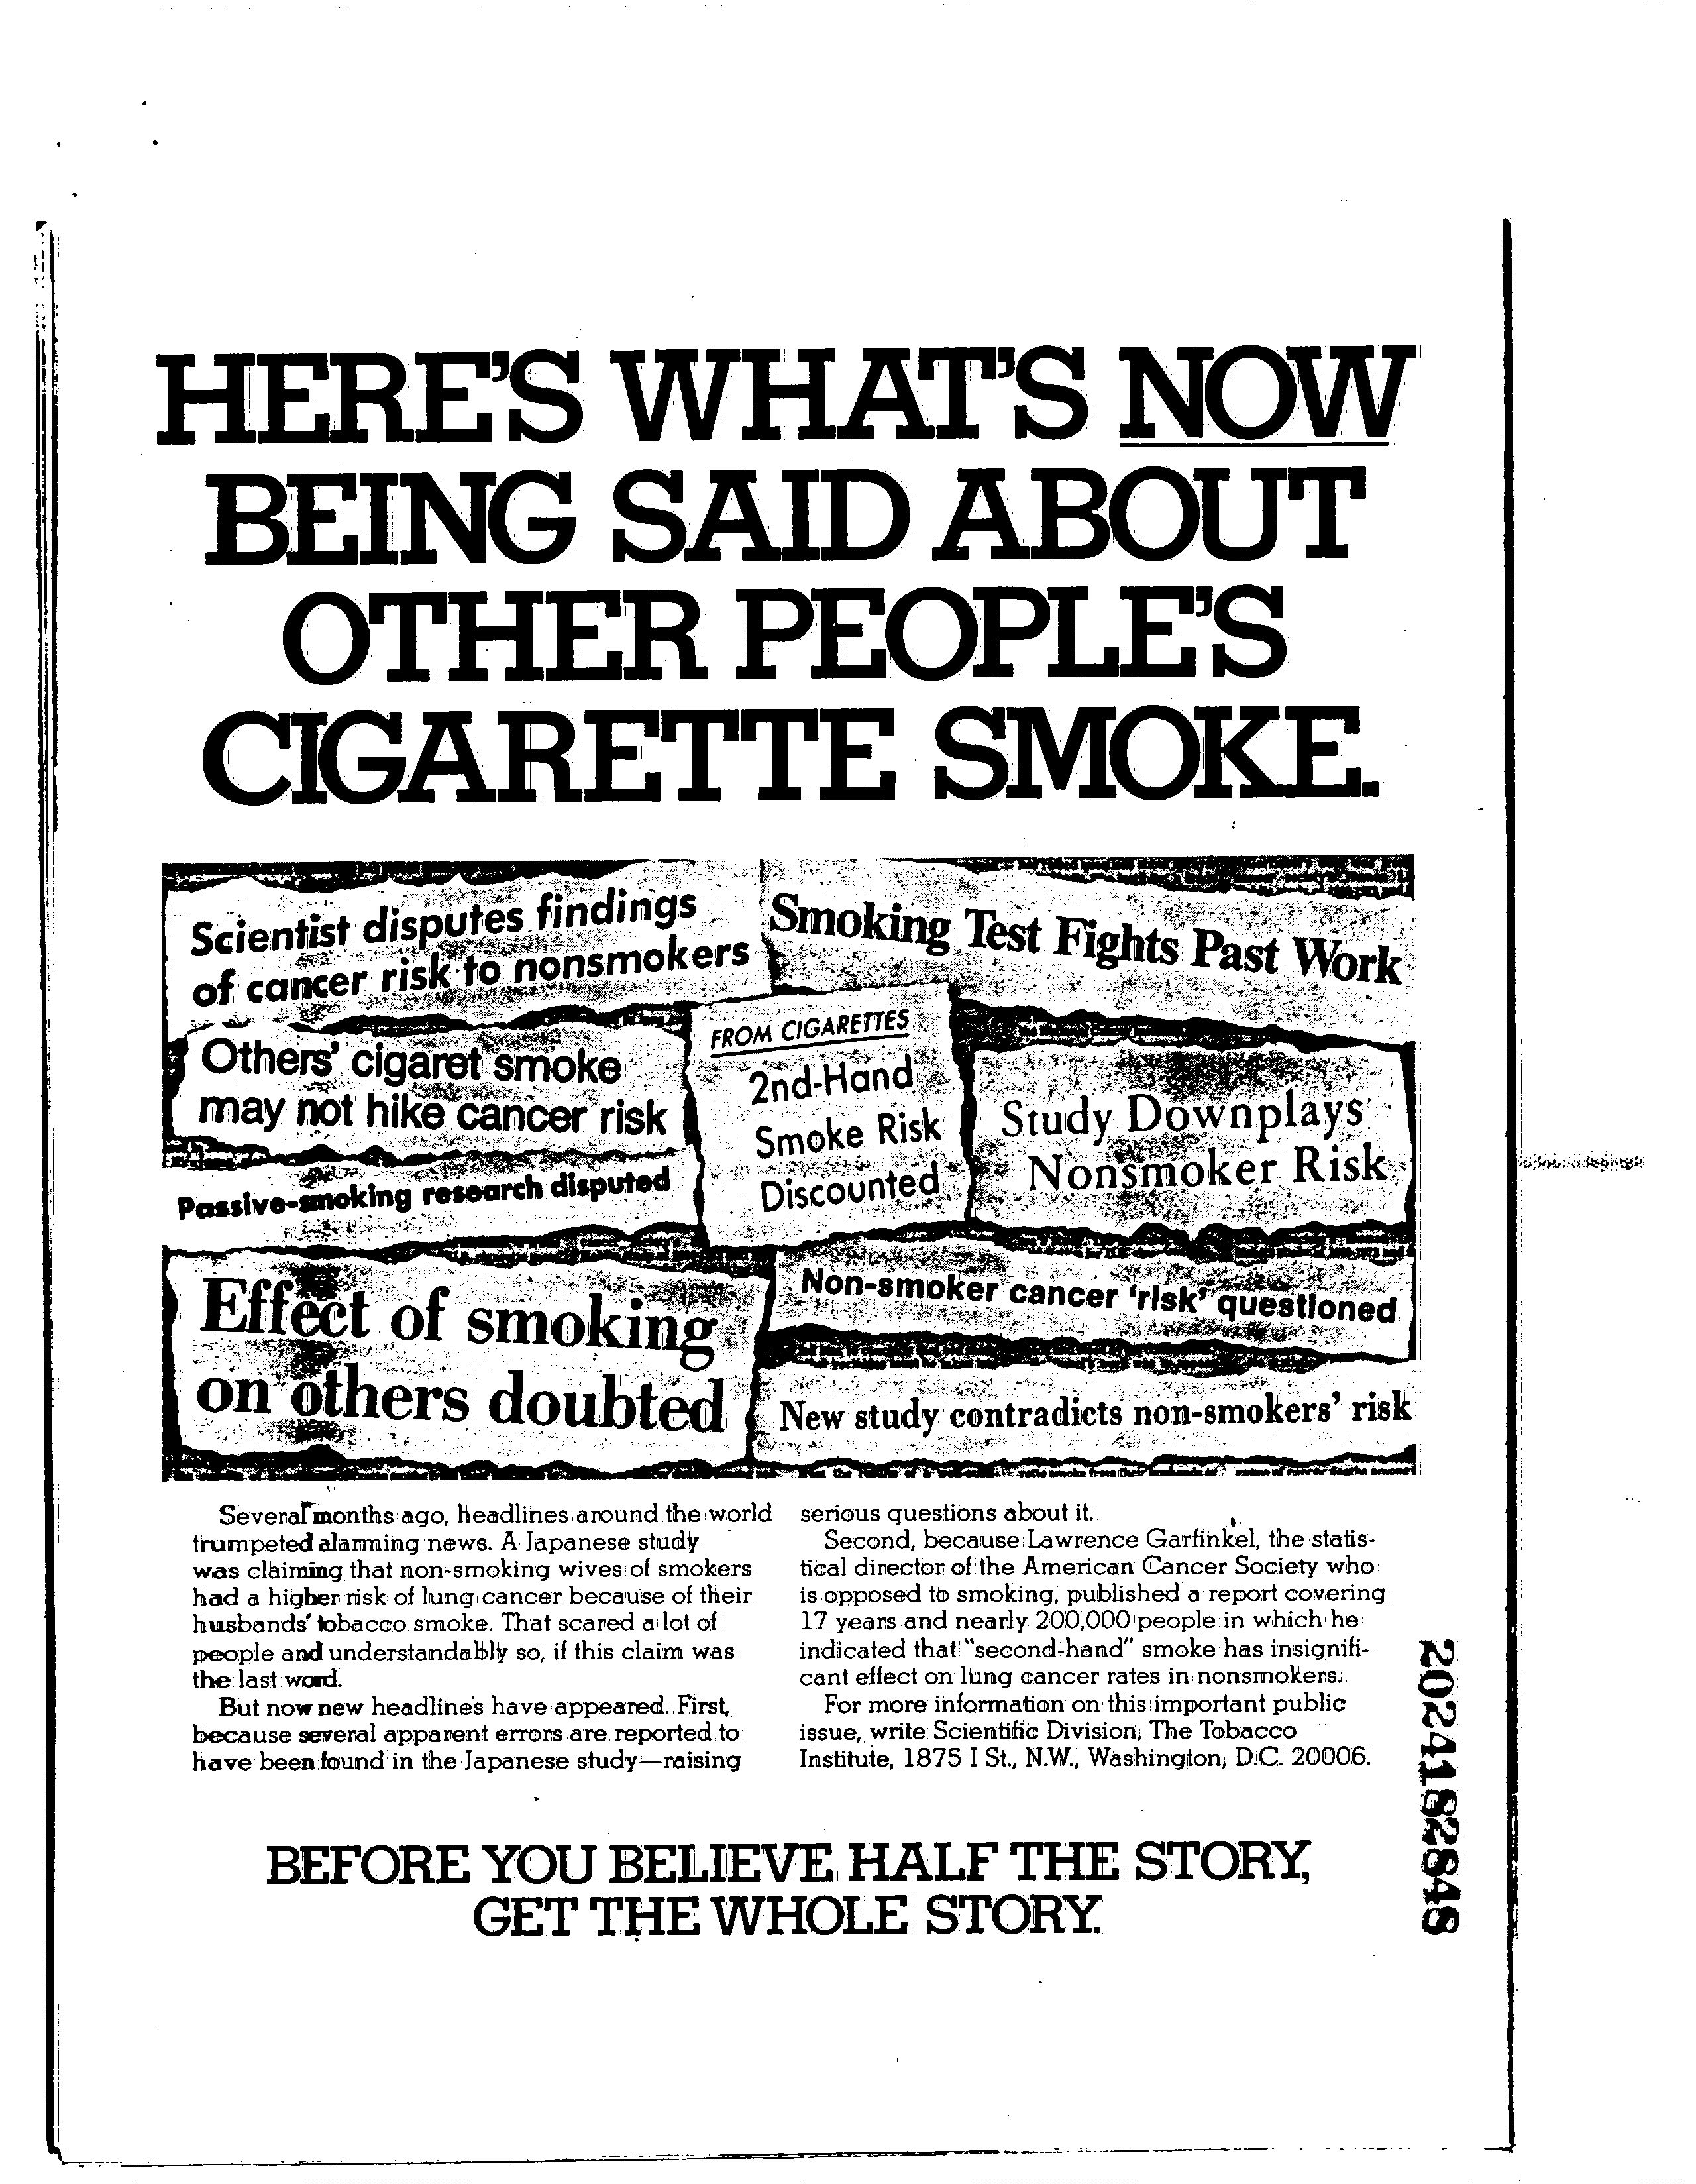

In [7]:
from IPython.display import Image, display

display(Image("2024182848.jpg"))